In [58]:

import json
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from collections import Counter
from scipy.stats import chi2_contingency
from itertools import combinations

warnings.filterwarnings("ignore")

In [59]:
BIAS_LABELS = [
    "gender", "religional", "caste", "religion",
    "appearence", "socialstatus", "amiguity",
    "political", "Age", "Disablity"
]

LABEL_NAMES = {
    "gender": "Gender",
    "religional": "Regional/Ethnic",
    "caste": "Caste",
    "religion": "Religion",
    "appearence": "Appearance",
    "socialstatus": "Social Status",
    "amiguity": "Ambiguity",
    "political": "Political",
    "Age": "Age",
    "Disablity": "Disability",
    "none": "None / No Bias",
}

In [60]:
PALETTE = sns.color_palette("Set2", len(BIAS_LABELS))

plt.rcParams.update({
    "figure.facecolor": "#FAFAFA",
    "axes.facecolor": "#FAFAFA",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "DejaVu Sans",
})

In [61]:
import pandas as pd
from pathlib import Path

DATA_DIR = "/home/sangy/Documents/Research-Work/nepali-bias-detection/webpage-for-data-collection/backend/data/labeled_data.json"

OUTPUT_DIR = Path("/home/sangy/Documents/Research-Work/nepali-bias-detection/webpage-for-data-collection/backend/new_data")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_json(DATA_DIR)

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1012 entries, 0 to 1011
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   text          1012 non-null   object 
 1   gender        1012 non-null   int64  
 2   religional    1012 non-null   int64  
 3   caste         1012 non-null   int64  
 4   religion      1012 non-null   int64  
 5   appearence    1012 non-null   int64  
 6   socialstatus  1012 non-null   int64  
 7   amiguity      1012 non-null   int64  
 8   political     1012 non-null   int64  
 9   Age           1012 non-null   int64  
 10  Disablity     1012 non-null   int64  
 11  none          1012 non-null   int64  
 12  comment       0 non-null      float64
dtypes: float64(1), int64(11), object(1)
memory usage: 102.9+ KB
None


In [62]:
with open(DATA_DIR, "r", encoding="utf-8") as f:
    raw = json.load(f)

df = pd.DataFrame(raw)

for col in BIAS_LABELS + ["none"]:
    if col not in df.columns:
        df[col] = 0
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0).astype(int)

if "comment" not in df.columns:
    df["comment"] = None

df.head()

,text,gender,religional,caste,religion,appearence,socialstatus,amiguity,political,Age,Disablity,none,comment
0,नयाँ शक्तिका संयोजक बाबुराम भट्टराई जस्ता अवसर...,0,0,0,0,0,0,0,1,0,0,0,None
1,कांग्रेसले गोरखा जस्ता पिछडिएका पहाडी क्षेत्रक...,0,1,0,0,0,0,0,1,0,0,0,None
2,गत स्थानीय निर्वाचनमा एक गाउँपालिका जितेको नया...,0,0,1,0,0,0,0,1,0,0,0,None
3,कांग्रेसका एक नेताले सोही विषयमा बुढा बाबुरामस...,0,0,0,0,0,0,0,1,1,0,0,None
4,‘उहाँले जित्ने भए त हामी दिइ नै हाल्थ्यौं तर उ...,0,0,0,0,0,0,0,1,0,1,0,None


In [63]:
print("Columns:", df.columns)

schema_issues = []
for col in BIAS_LABELS + ["none"]:
    if not set(df[col].unique()).issubset({0,1}):
        schema_issues.append(col)

print("Schema issues:", schema_issues)

print("Duplicates:", df.duplicated(subset=["text"]).sum())
print("Missing values:\n", df.isnull().sum())

Columns: Index(['text', 'gender', 'religional', 'caste', 'religion', 'appearence',
       'socialstatus', 'amiguity', 'political', 'Age', 'Disablity', 'none',
       'comment'],
      dtype='object')
Schema issues: []
Duplicates: 0
Missing values:
 text               0
gender             0
religional         0
caste              0
religion           0
appearence         0
socialstatus       0
amiguity           0
political          0
Age                0
Disablity          0
none               0
comment         1012
dtype: int64


# Label Distribution Accross Bias Categories

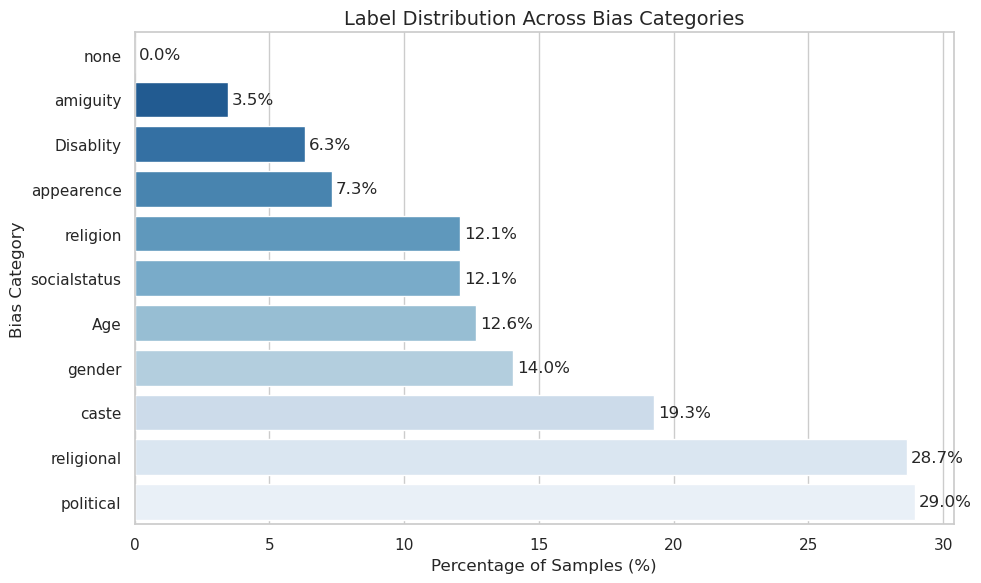

In [64]:
label_stats = {
    col: (df[col].sum() / len(df)) * 100
    for col in BIAS_LABELS + ["none"]
}

stats_df = pd.DataFrame(
    list(label_stats.items()),
    columns=["label", "pct_positive"]
)

stats_df = stats_df.sort_values("pct_positive")

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=stats_df,
    x="pct_positive",
    y="label",
    palette="Blues_r"
)


for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.title("Label Distribution Across Bias Categories", fontsize=14)
plt.xlabel("Percentage of Samples (%)")
plt.ylabel("Bias Category")

plt.tight_layout()
plt.show()

# Bias Label Co-occurrence Matrix Heatmap

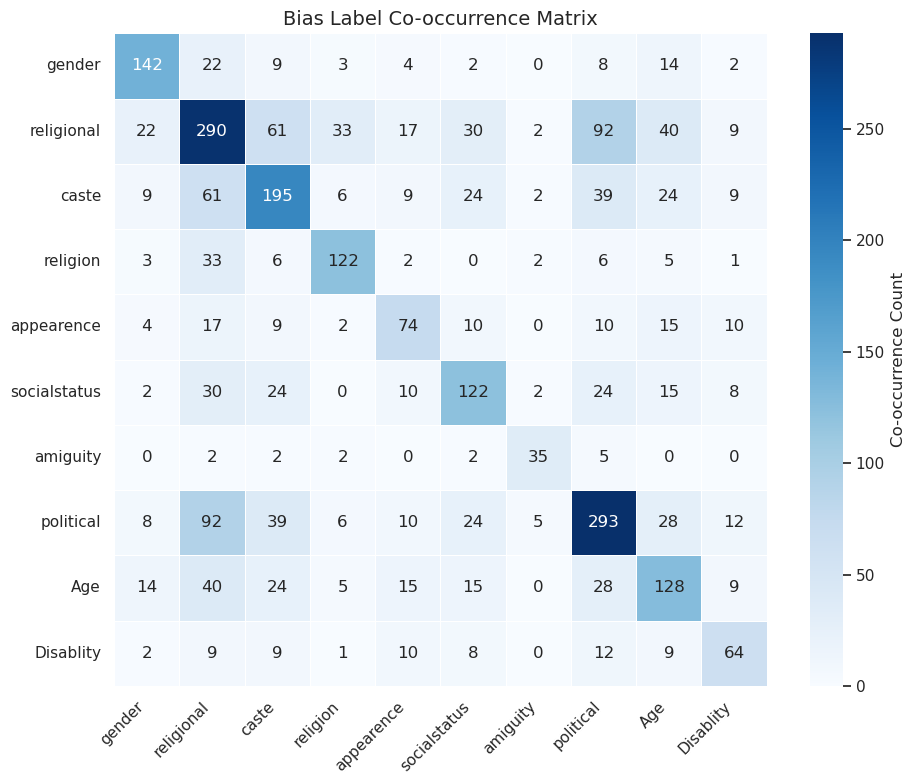

In [65]:
label_matrix = df[BIAS_LABELS].values
cooc_matrix = label_matrix.T @ label_matrix  # dot product = co-occurrence

cooc_df = pd.DataFrame(
    cooc_matrix,
    index=BIAS_LABELS,
    columns=BIAS_LABELS
)

sns.set_theme(style="white")

plt.figure(figsize=(10, 8))

ax = sns.heatmap(
    cooc_df,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5,
    square=True,
    cbar_kws={"label": "Co-occurrence Count"}
)

plt.title("Bias Label Co-occurrence Matrix", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

# Bias Label Co-occurrence

The co-occurrence heatmap shows how often two bias labels appear together in the same sample.

- Each cell represents the number of times two labels co-occur.
- Darker values indicate stronger relationships between bias categories.
- The diagonal shows self-occurrence (always highest).

## Key Insight
This helps identify whether bias labels are independent or tend to appear together, which is important for multi-label modeling.

# Histogram And KDE Distribution

In [68]:
def token_count(t): return len(str(t).split())
def char_count(t): return len(str(t))

df["token_count"] = df["text"].apply(token_count)
df["char_count"] = df["text"].apply(char_count)

df[["token_count","char_count"]].describe()

,token_count,char_count
count,1012.000000,1012.000000
mean,11.603755,79.932806
std,8.208467,54.901922
min,3.000000,24.000000
25%,6.000000,44.000000
50%,8.000000,59.000000
75%,14.000000,93.000000
max,48.000000,342.000000


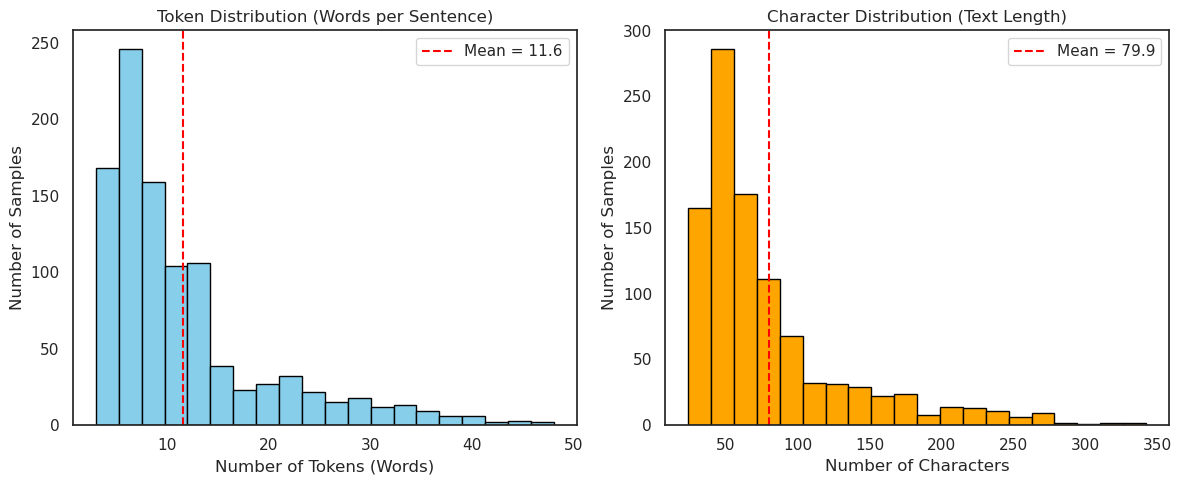

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df["token_count"], bins=20, color="skyblue", edgecolor="black")
axes[0].set_title("Token Distribution (Words per Sentence)")
axes[0].set_xlabel("Number of Tokens (Words)")
axes[0].set_ylabel("Number of Samples")

mean_tokens = df["token_count"].mean()
axes[0].axvline(mean_tokens, color="red", linestyle="--", label=f"Mean = {mean_tokens:.1f}")
axes[0].legend()

axes[1].hist(df["char_count"], bins=20, color="orange", edgecolor="black")
axes[1].set_title("Character Distribution (Text Length)")
axes[1].set_xlabel("Number of Characters")
axes[1].set_ylabel("Number of Samples")

mean_chars = df["char_count"].mean()
axes[1].axvline(mean_chars, color="red", linestyle="--", label=f"Mean = {mean_chars:.1f}")
axes[1].legend()

plt.tight_layout()
plt.show()

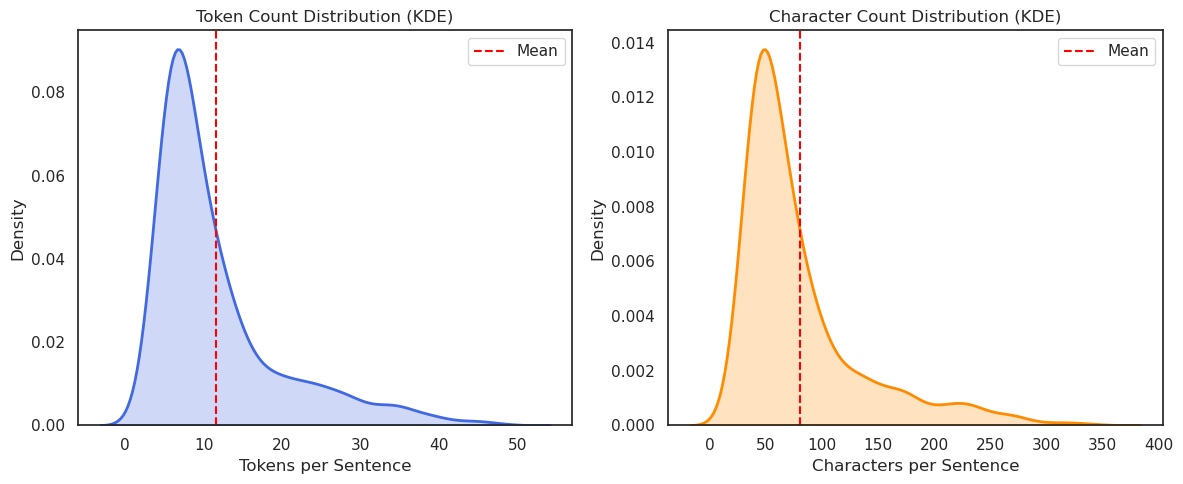

In [70]:
plt.figure(figsize=(12, 5))

# Token Distribution KDE
plt.subplot(1, 2, 1)
sns.kdeplot(
    df["token_count"],
    fill=True,
    color="royalblue",
    linewidth=2
)

plt.axvline(df["token_count"].mean(), color="red", linestyle="--", label="Mean")
plt.title("Token Count Distribution (KDE)")
plt.xlabel("Tokens per Sentence")
plt.ylabel("Density")
plt.legend()


# Character Distribution KDE
plt.subplot(1, 2, 2)
sns.kdeplot(
    df["char_count"],
    fill=True,
    color="darkorange",
    linewidth=2
)

plt.axvline(df["char_count"].mean(), color="red", linestyle="--", label="Mean")
plt.title("Character Count Distribution (KDE)")
plt.xlabel("Characters per Sentence")
plt.ylabel("Density")
plt.legend()

plt.tight_layout()
plt.show()

We use both Histogram and KDE plots to understand the distribution of token and character lengths in the dataset.

## Histogram
Histogram shows the **frequency of samples in each bin**.

- Helps see how many sentences fall in each range
- Useful for detecting outliers and data spread
- Gives a discrete view of the dataset

## KDE (Kernel Density Estimation)
KDE shows a **smooth probability distribution** of the data.

- Y-axis represents probability density (not count)
- Helps understand the overall shape of the distribution
- Less noisy and more suitable for analysis and reports

## Key Difference
- Histogram = actual counts  
- KDE = smooth trend of data distribution  

Both together give a clear understanding of dataset length patterns.

# Token Distribution by bias label

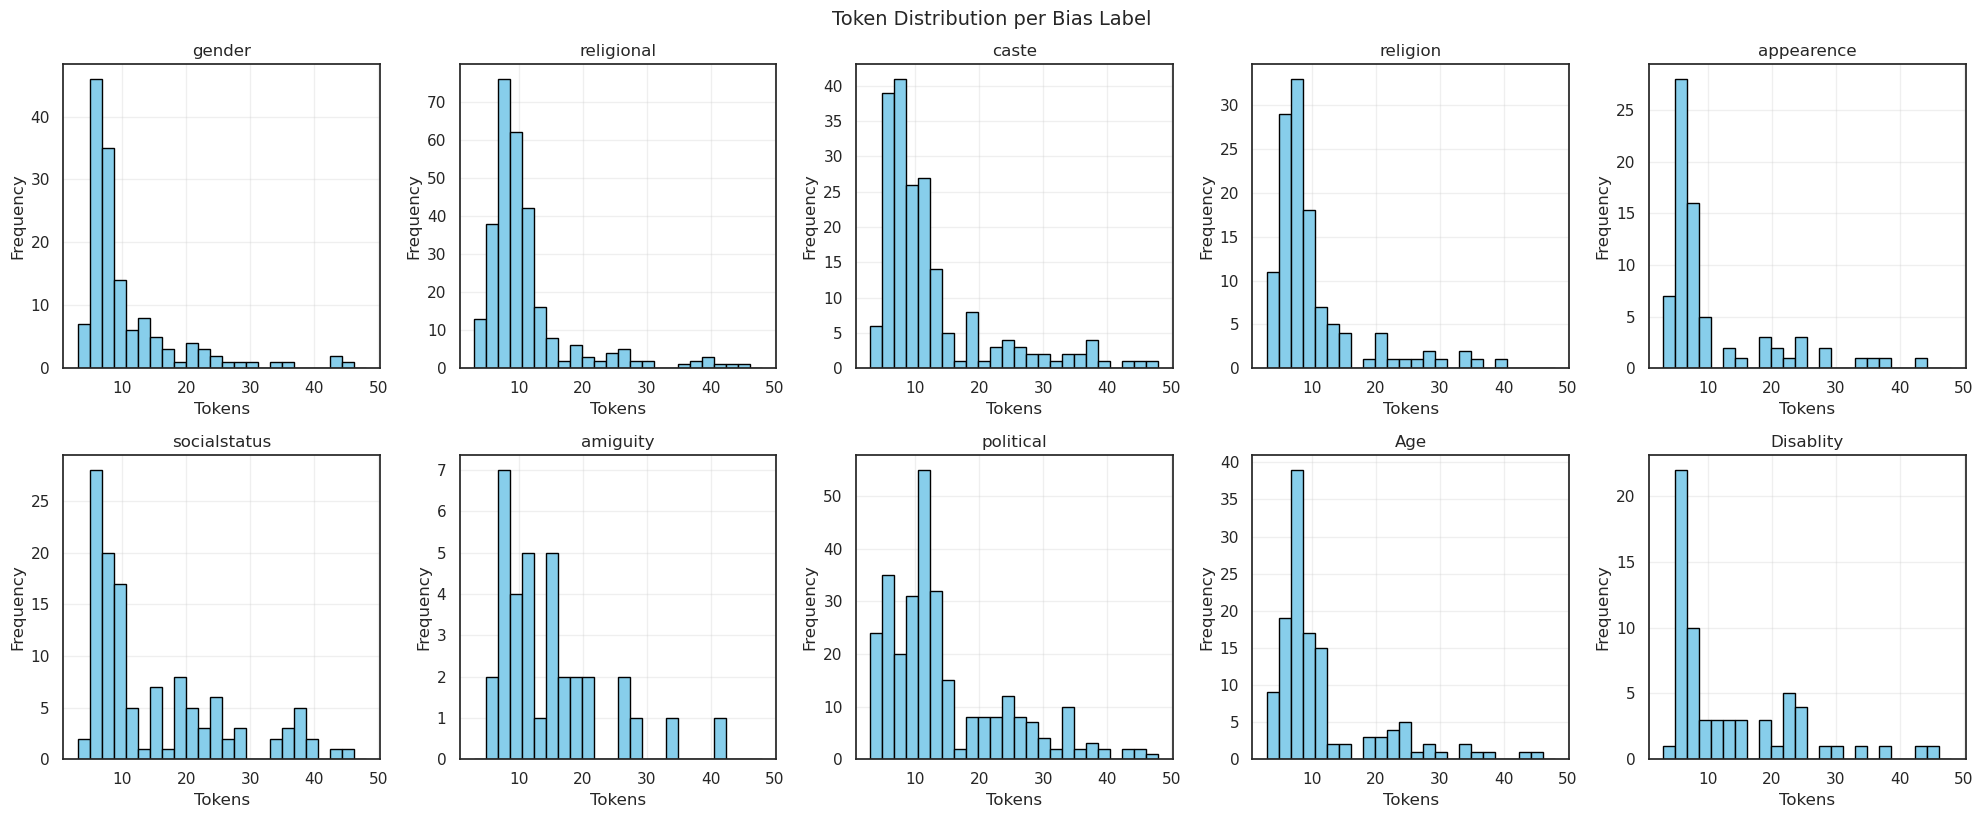

In [71]:
n_labels = len(BIAS_LABELS)

fig, axes = plt.subplots(2, 5, figsize=(20, 8))  # adjust if needed
axes = axes.flatten()

bins = np.linspace(
    df["token_count"].min(),
    df["token_count"].max(),
    25
)

for i, col in enumerate(BIAS_LABELS):
    ax = axes[i]
    data = df[df[col] == 1]["token_count"]

    ax.hist(data, bins=bins, color="skyblue", edgecolor="black")
    ax.set_title(col)
    ax.set_xlabel("Tokens")
    ax.set_ylabel("Frequency")
    ax.grid(alpha=0.3)

# remove empty plots (if any)
for j in range(len(BIAS_LABELS), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle("Token Distribution per Bias Label", y=1.02, fontsize=14)
plt.show()

# Boxplot Analysis on tokens distribution per label

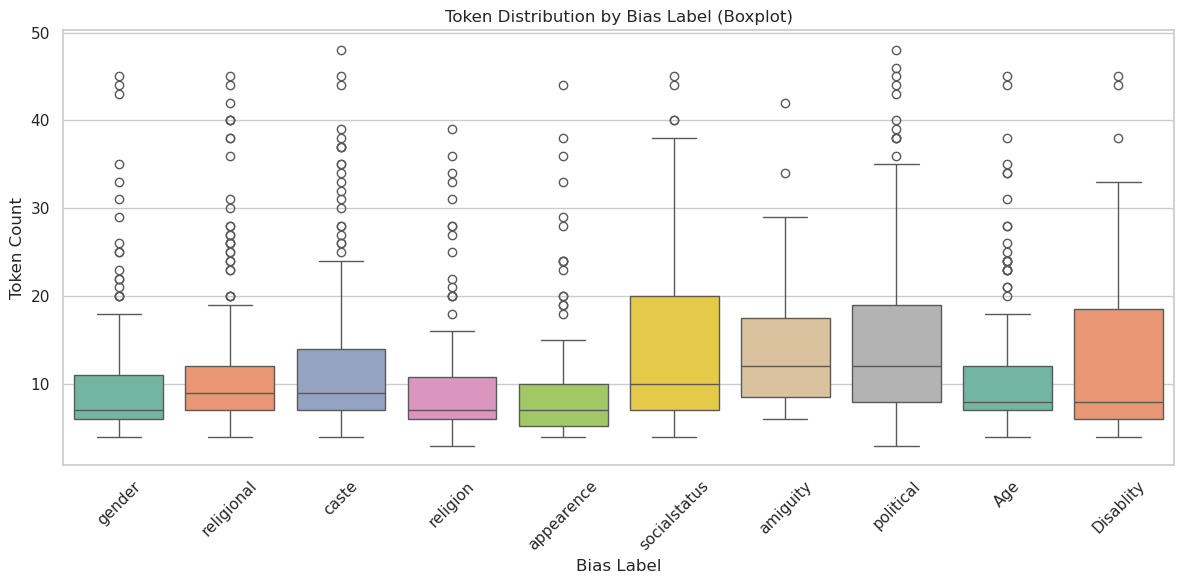

In [72]:
plot_data = []

for col in BIAS_LABELS:
    temp = df[df[col] == 1][["token_count"]].copy()
    temp["label"] = col
    plot_data.append(temp)

box_df = pd.concat(plot_data)

plt.figure(figsize=(12, 6))

sns.set_theme(style="whitegrid")

sns.boxplot(
    data=box_df,
    x="label",
    y="token_count",
    palette="Set2"
)

plt.title("Token Distribution by Bias Label (Boxplot)")
plt.xlabel("Bias Label")
plt.ylabel("Token Count")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Boxplot Analysis: Token Distribution by Bias Label
This boxplot illustrates the distribution of token counts across different bias categories in a multi-label NLP dataset. It reveals significant variation in sentence lengths, with Political, Religional, and Caste biases showing the highest medians (≈18–23 tokens) and widest spreads, while Appearance has the shortest sentences (median ≈7 tokens).
## Key Insights:

- Longer sentences are more common in complex bias types (Political, Religional, Caste), likely due to contextual explanations.
- High variability and outliers in several categories indicate inconsistent text lengths.
- This length imbalance can affect fine-tuning by causing truncation issues for long samples and inefficient padding for short ones.

# Chi-square & Length Association Plots

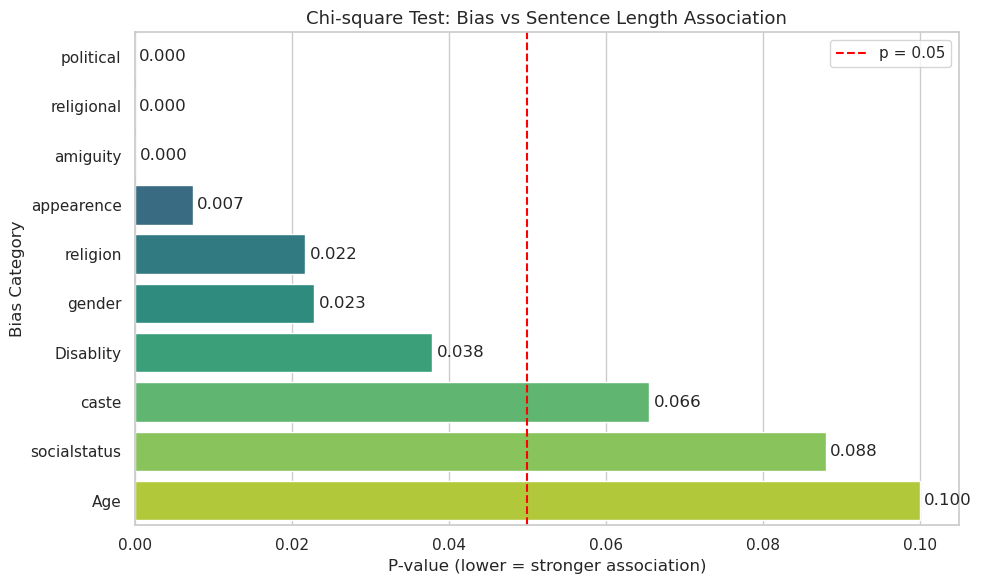

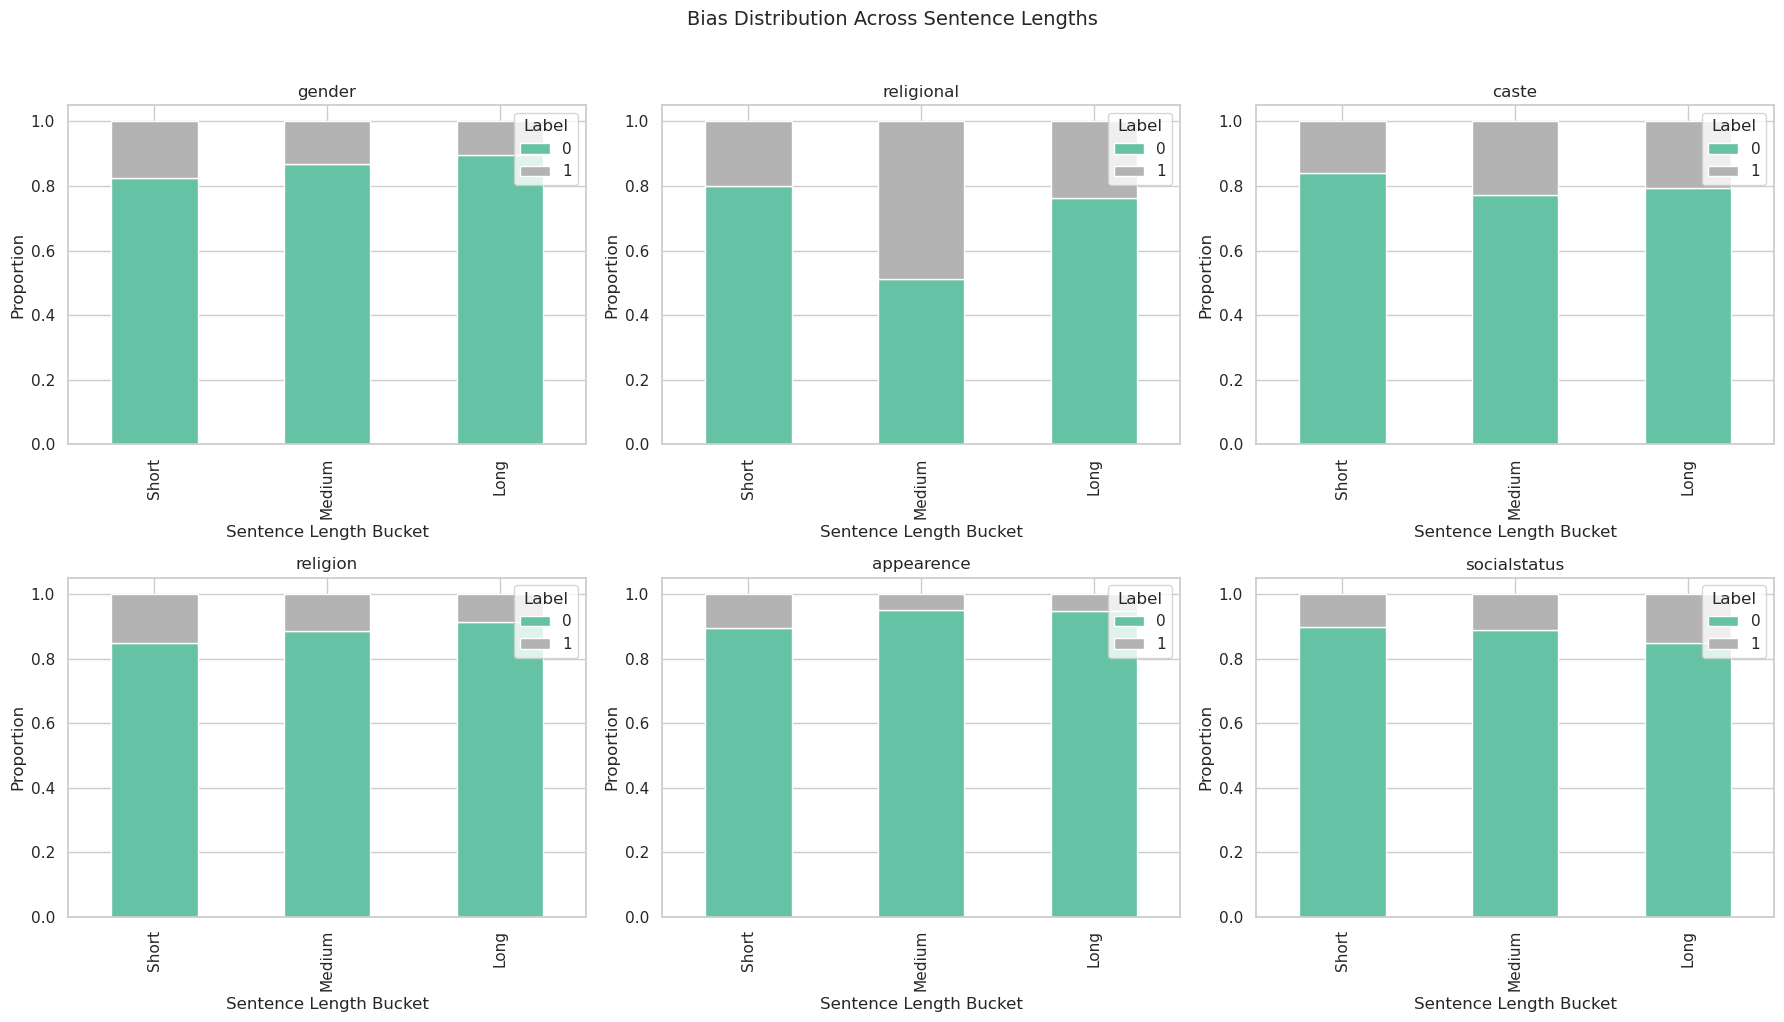

In [73]:

df["bucket"] = pd.qcut(
    df["token_count"],
    3,
    labels=["Short", "Medium", "Long"]
)


results = []

for col in BIAS_LABELS:
    ct = pd.crosstab(df["bucket"], df[col])

    if ct.shape == (3, 2):
        chi2, p, _, _ = chi2_contingency(ct)
        results.append({
            "Bias": col,
            "Chi2": chi2,
            "p_value": p
        })

result_df = pd.DataFrame(results).sort_values("p_value")

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=result_df,
    x="p_value",
    y="Bias",
    palette="viridis"
)

plt.axvline(0.05, color="red", linestyle="--", label="p = 0.05")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)

plt.title("Chi-square Test: Bias vs Sentence Length Association", fontsize=13)
plt.xlabel("P-value (lower = stronger association)")
plt.ylabel("Bias Category")

plt.legend()
plt.tight_layout()
plt.show()

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(BIAS_LABELS[:6]):
    prop = pd.crosstab(df["bucket"], df[col], normalize="index")

    prop.plot(
        kind="bar",
        stacked=True,
        ax=axes[i],
        colormap="Set2"
    )

    axes[i].set_title(col)
    axes[i].set_xlabel("Sentence Length Bucket")
    axes[i].set_ylabel("Proportion")
    axes[i].legend(title="Label", loc="upper right")

# remove empty subplots if any
for j in range(len(BIAS_LABELS[:6]), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Bias Distribution Across Sentence Lengths", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [74]:
result_df

,Bias,Chi2,p_value
7,political,85.088672,3.336028e-19
1,religional,70.746831,4.340311e-16
6,amiguity,18.630364,9.004670e-05
4,appearence,9.809812,7.410141e-03
3,religion,7.658420,2.172677e-02
0,gender,7.555064,2.287908e-02
9,Disablity,6.545033,3.791091e-02
2,caste,5.449898,6.554954e-02
5,socialstatus,4.859991,8.803724e-02
8,Age,4.605793,9.996887e-02


This analysis shows the relationship between **sentence length (Short, Medium, Long)** and **bias labels** using Chi-square tests and stacked bar plots.

---

##  1. P-value Bar Plot

- Each bar represents a bias label
- X-axis shows the **p-value**
- Red line at **0.05 threshold**

###  Interpretation:

- **p < 0.05** → Strong relationship between sentence length and bias label
- **p > 0.05** → No significant relationship (likely random)

 Lower p-value means stronger statistical association.

---

##  2. Stacked Bar Plot

- Shows distribution of each bias label across:
  - Short
  - Medium
  - Long sentences

###  Interpretation:

- Each bar = 100% of samples for that label
- Different colors show proportion in each length bucket

###  What to look for:
- If one color dominates → label is biased toward that sentence length
- Balanced colors → no strong length dependency

---

##  Key Insight

This analysis helps detect whether **sentence length is correlated with specific bias labels**, which is important to avoid unintended bias in model training.

# Dataset Quality Radar Chart

In [75]:
scores = {}

scores["completeness"] = 1 - df.isnull().sum().sum() / (len(df) * len(df.columns))
scores["label_coverage"] = 1 - ((df[BIAS_LABELS].sum(axis=1) == 0).sum() / len(df))
scores["no_duplicates"] = 1 - df.duplicated().sum() / len(df)

scores["script_purity"] = df["text"].apply(
    lambda x: sum(1 for c in str(x) if '\u0900' <= c <= '\u097F') / max(len(str(x)),1)
).mean()

scores["schema_validity"] = 1.0
scores["none_consistency"] = 1 - ((df["none"] == 1) & (df[BIAS_LABELS].sum(axis=1) > 0)).sum() / len(df)

scores

{'completeness': np.float64(0.9375),
 'label_coverage': np.float64(0.9990118577075099),
 'no_duplicates': np.float64(1.0),
 'script_purity': np.float64(0.866161335713795),
 'schema_validity': 1.0,
 'none_consistency': np.float64(1.0)}

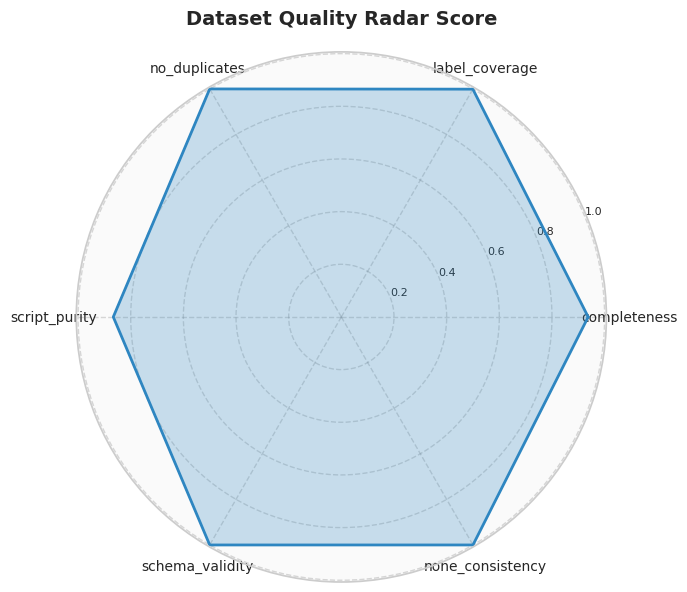

In [76]:
labels = list(scores.keys())
values = list(scores.values())

# close the loop
values += values[:1]

# angles
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]


plt.figure(figsize=(7, 7))
ax = plt.subplot(111, polar=True)

# background style
ax.set_facecolor("#FAFAFA")
plt.grid(color="gray", linestyle="--", alpha=0.3)


ax.plot(
    angles,
    values,
    linewidth=2,
    color="#2E86C1"
)

ax.fill(
    angles,
    values,
    color="#2E86C1",
    alpha=0.25
)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=10)

ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8", "1.0"], fontsize=8)

ax.set_title(
    "Dataset Quality Radar Score",
    fontsize=14,
    fontweight="bold",
    pad=20
)

plt.tight_layout()
plt.show()

The radar chart visualizes different **dataset quality metrics** on a normalized scale from 0 to 1.

Each axis represents one quality aspect of the dataset, and the shape formed by connecting all points shows the overall dataset quality profile.

---

##  What the graph shows

- Each **axis = one quality metric** (e.g., completeness, script purity)
- Each **value = score between 0 and 1**
- The **outer edge (1.0)** represents perfect quality
- The **center (0.0)** represents poor quality

---

##  Key Interpretation

###  Large outer shape
- Indicates **high-quality dataset**
- Most metrics are close to 1

### Uneven shape
- Shows imbalance in dataset quality
- Some metrics are weaker than others

###  Small dips toward center
- Represent weak areas in the dataset
- These may need cleaning or improvement

---

##  Metric-wise meaning

- **Completeness** → How much data is missing
- **Label coverage** → How well data is annotated
- **No duplicates** → Dataset uniqueness
- **Script purity** → Level of Nepali (Devanagari) text
- **Schema validity** → Structural correctness
- **None consistency** → Logical consistency of labels

---

## Overall Insight

The radar chart provides a **quick visual summary of dataset quality**, helping identify strengths and weaknesses across multiple dimensions in a single view.